# DermaAssist AI — Skin Disease Classification Pipeline
**EfficientNetB0 Transfer Learning | 10-Class | Publication-Ready**

| Item | Detail |
|---|---|
| Dataset | Skin Diseases Image Dataset (ismailpromus, Kaggle) |
| Classes | 10 skin disease categories |
| Model | EfficientNetB0 (ImageNet pretrained) |
| Strategy | Two-phase: feature extraction → fine-tuning |
| Outputs | .h5 model, TFLite model, Grad-CAM, metrics |
| Target | Conference/journal publication |

---

## 0. Environment Setup & GPU Check

In [1]:
# Install dependencies (run once)
!pip install -q kaggle tensorflow matplotlib seaborn scikit-learn opencv-python-headless Pillow tqdm

import os, random, warnings, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU available: {[g.name for g in gpus]}')
else:
    print('⚠️  No GPU found — training on CPU (will be slow). Use Kaggle/Colab for GPU.')

print(f'TensorFlow version: {tf.__version__}')

✅ GPU available: ['/physical_device:GPU:0', '/physical_device:GPU:1']
TensorFlow version: 2.20.0


## 1. Dataset Download (Kaggle API)

In [3]:

# ──────────────────────────────────────────────────────────────────────────────
# SET YOUR DATA ROOT HERE
# ──────────────────────────────────────────────────────────────────────────────
DATA_ROOT = '/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES'

# Verify structure
data_path = Path(DATA_ROOT)
if data_path.exists():
    classes = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
    print(f'✅ Dataset found at: {DATA_ROOT}')
    print(f'   Classes ({len(classes)}): {classes}')
else:
    print(f'❌ Dataset not found at {DATA_ROOT}. Please download first.')

✅ Dataset found at: /kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES
   Classes (10): ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


## 2. Exploratory Data Analysis (EDA)

In [4]:
# ── Class distribution ────────────────────────────────────────────────────────
class_counts = {}
all_image_paths = []
all_labels = []

for cls in classes:
    cls_path = data_path / cls
    imgs = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.jpeg')) + \
           list(cls_path.glob('*.png')) + list(cls_path.glob('*.JPG'))
    class_counts[cls] = len(imgs)
    all_image_paths.extend(imgs)
    all_labels.extend([cls] * len(imgs))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})

print(f'Total images: {len(df):,}')
print('\nClass distribution:')
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    bar = '█' * (count // 200)
    print(f'  {cls:<55} {count:>5} {bar}')

Total images: 27,153

Class distribution:
  5. Melanocytic Nevi (NV) - 7970                          7970 ███████████████████████████████████████
  4. Basal Cell Carcinoma (BCC) 3323                       3323 ████████████████
  2. Melanoma 15.75k                                       3140 ███████████████
  10. Warts Molluscum and other Viral Infections - 2103    2103 ██████████
  6. Benign Keratosis-like Lesions (BKL) 2624              2079 ██████████
  7. Psoriasis pictures Lichen Planus and related diseases - 2k  2055 ██████████
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k   1847 █████████
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k  1702 ████████
  1. Eczema 1677                                           1677 ████████
  3. Atopic Dermatitis - 1.25k                             1257 ██████


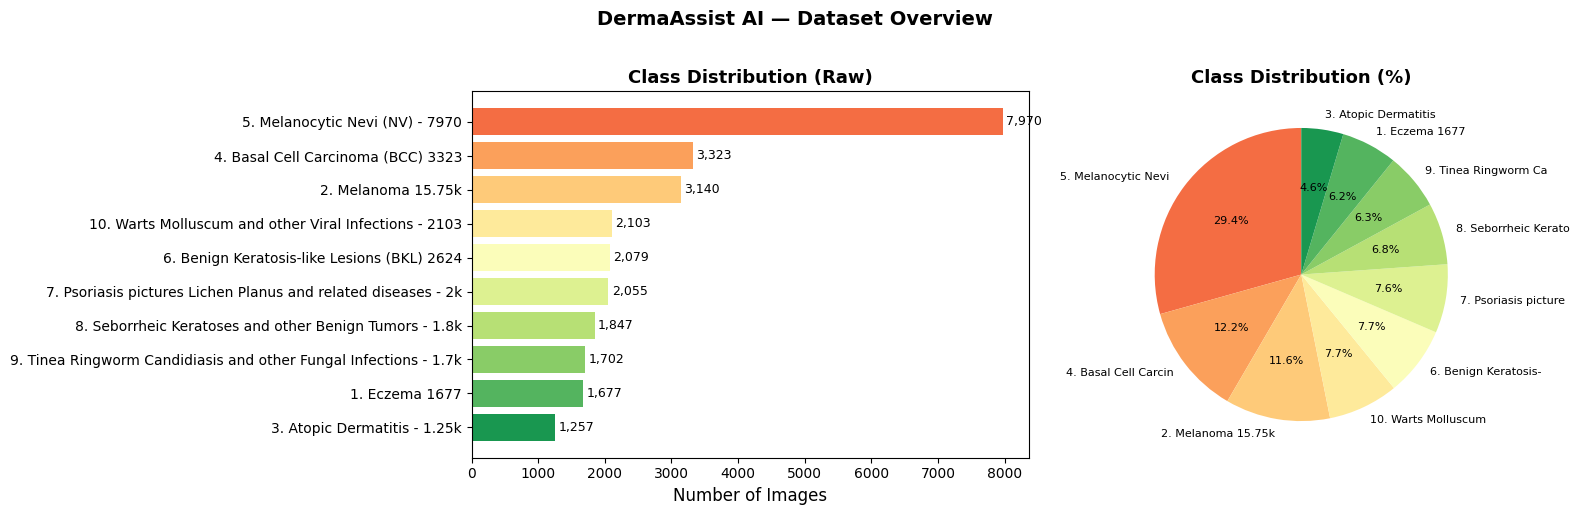

📊 Figure saved: fig1_class_distribution.png


In [5]:
# ── Plot class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
sorted_classes = sorted(class_counts, key=class_counts.get, reverse=True)
sorted_counts = [class_counts[c] for c in sorted_classes]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_classes)))

bars = axes[0].barh(sorted_classes, sorted_counts, color=colors)
axes[0].set_xlabel('Number of Images', fontsize=12)
axes[0].set_title('Class Distribution (Raw)', fontsize=13, fontweight='bold')
for bar, count in zip(bars, sorted_counts):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=9)
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(sorted_counts, labels=[c[:20] for c in sorted_classes],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 8})
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('DermaAssist AI — Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('📊 Figure saved: fig1_class_distribution.png')

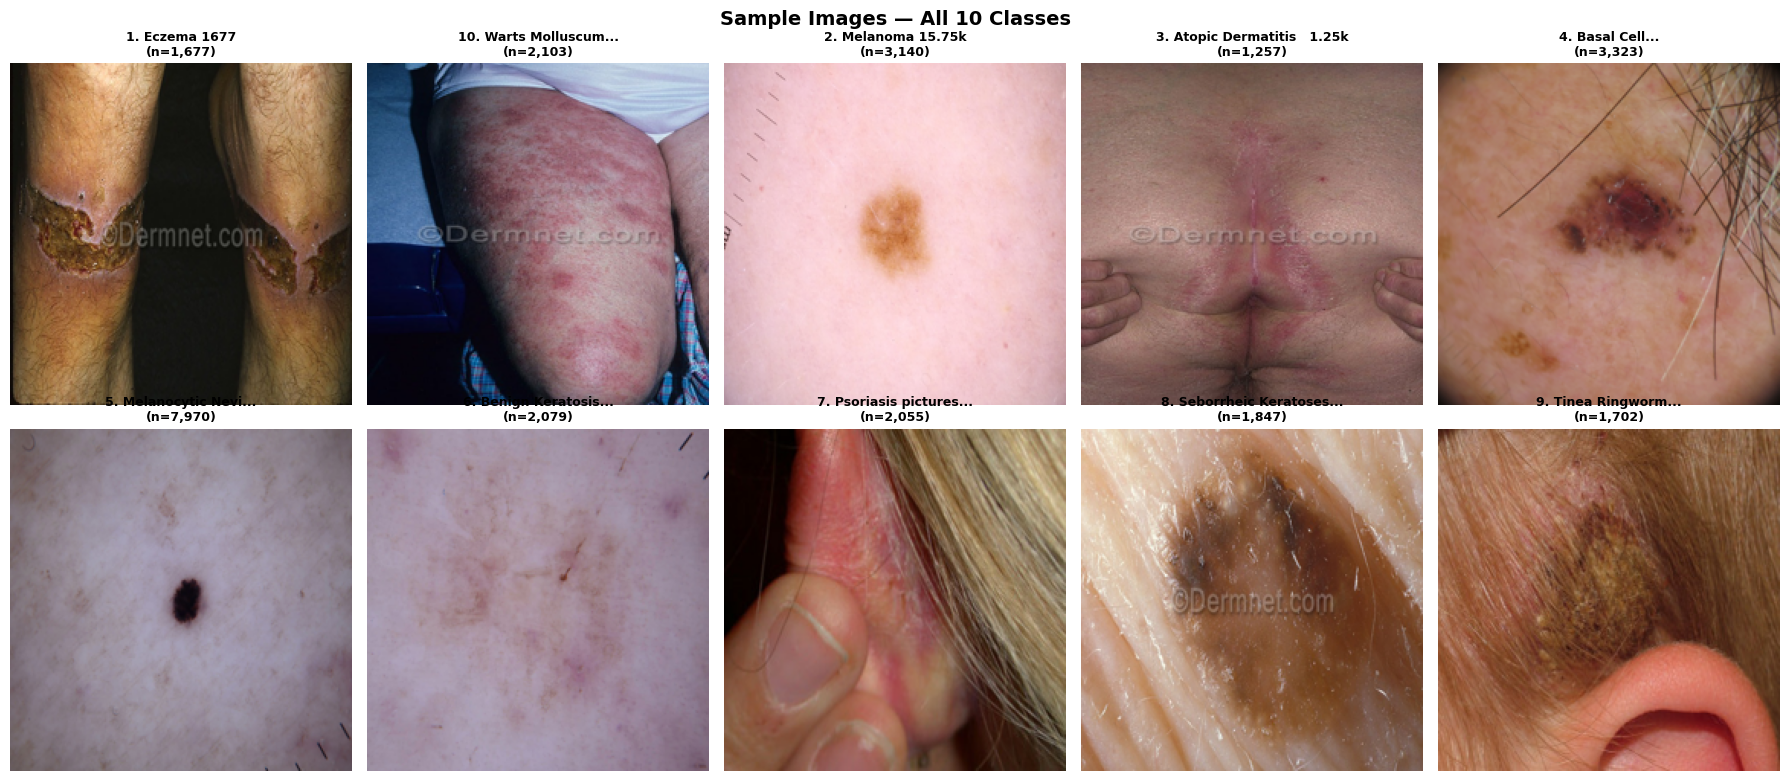

📊 Figure saved: fig2_sample_images.png


In [6]:
# ── Sample images per class ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = data_path / cls
    sample_imgs = list(cls_path.glob('*.jpg'))[:1] + list(cls_path.glob('*.png'))[:1]
    if sample_imgs:
        img = Image.open(sample_imgs[0]).convert('RGB').resize((224, 224))
        axes[idx].imshow(img)
        # Clean class name for display
        display_name = cls.replace('_', ' ').replace('-', ' ')
        if len(display_name) > 30:
            words = display_name.split()
            display_name = ' '.join(words[:3]) + '...'
        axes[idx].set_title(f'{display_name}\n(n={class_counts[cls]:,})',
                            fontsize=9, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images — All 10 Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()
print('📊 Figure saved: fig2_sample_images.png')

In [7]:
# ── Image resolution analysis ─────────────────────────────────────────────────
print('Analyzing image resolutions (sampling 500 images)...')
sample_paths = df['path'].sample(min(500, len(df)), random_state=SEED).tolist()
widths, heights = [], []

for p in tqdm(sample_paths):
    try:
        with Image.open(p) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        pass

print(f'Width  — mean: {np.mean(widths):.0f}, min: {min(widths)}, max: {max(widths)}')
print(f'Height — mean: {np.mean(heights):.0f}, min: {min(heights)}, max: {max(heights)}')
print(f'→ All images will be resized to 224×224 for EfficientNetB0')

Analyzing image resolutions (sampling 500 images)...


100%|██████████| 500/500 [00:03<00:00, 154.21it/s]

Width  — mean: 691, min: 294, max: 1024
Height — mean: 594, min: 222, max: 1024
→ All images will be resized to 224×224 for EfficientNetB0


## 3. Configuration

In [8]:
# ── Central config — change these to experiment ───────────────────────────────
CFG = {
    # Image
    'IMG_SIZE':         224,
    'CHANNELS':         3,

    # Classes
    'NUM_CLASSES':      len(classes),
    'CLASS_NAMES':      classes,

    # Balancing: cap majority classes, min-augment minority
    'MAX_PER_CLASS':    2500,   # cap Nevi (7970) and others
    'MIN_PER_CLASS':    1500,   # augment Atopic Dermatitis (1257) to this

    # Splits
    'TRAIN_RATIO':      0.70,
    'VAL_RATIO':        0.15,
    'TEST_RATIO':       0.15,

    # Training Phase 1 (frozen base)
    'PHASE1_EPOCHS':    20,
    'PHASE1_LR':        1e-3,
    'BATCH_SIZE':       32,

    # Training Phase 2 (fine-tuning)
    'PHASE2_EPOCHS':    30,
    'PHASE2_LR':        1e-5,
    'UNFREEZE_FROM':    100,    # unfreeze EfficientNetB0 layers from this index

    # Regularization
    'DROPOUT':          0.4,
    'L2_REG':           1e-4,

    # Paths
    'CHECKPOINT_P1':    'best_model_phase1.h5',
    'CHECKPOINT_P2':    'best_model_phase2.h5',
    'TFLITE_PATH':      'dermaassist_model.tflite',
    'LOG_P1':           'training_log_phase1.csv',
    'LOG_P2':           'training_log_phase2.csv',
}

# Save config for reproducibility
with open('config.json', 'w') as f:
    json.dump({k: str(v) if not isinstance(v, (int, float, list)) else v
               for k, v in CFG.items()}, f, indent=2)

print('Configuration:')
for k, v in CFG.items():
    print(f'  {k:<20} = {v}')

Configuration:
  IMG_SIZE             = 224
  CHANNELS             = 3
  NUM_CLASSES          = 10
  CLASS_NAMES          = ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']
  MAX_PER_CLASS        = 2500
  MIN_PER_CLASS        = 1500
  TRAIN_RATIO          = 0.7
  VAL_RATIO            = 0.15
  TEST_RATIO           = 0.15
  PHASE1_EPOCHS        = 20
  PHASE1_LR            = 0.001
  BATCH_SIZE           = 32
  PHASE2_EPOCHS        = 30
  PHASE2_LR            = 1e-05
  UNFREEZE_FROM        = 100
  DROPOUT              = 0.4
  L2_REG               = 0.0001
  CHECKPOINT_P1        = best_model_phase1.h5
  CH

## 4. Data Balancing & Splits

In [9]:
# ── Balance dataset: cap majority, note minority for augmentation ─────────────
balanced_paths = []
balanced_labels = []

print('Balancing dataset:')
for cls in classes:
    cls_df = df[df['label'] == cls]
    n = len(cls_df)

    if n > CFG['MAX_PER_CLASS']:
        # Undersample majority classes
        cls_df = cls_df.sample(CFG['MAX_PER_CLASS'], random_state=SEED)
        action = f'undersampled {n} → {CFG["MAX_PER_CLASS"]}'
    elif n < CFG['MIN_PER_CLASS']:
        # Oversample minority classes (duplicates; augmentation handles variety)
        extra = CFG['MIN_PER_CLASS'] - n
        extra_df = cls_df.sample(extra, replace=True, random_state=SEED)
        cls_df = pd.concat([cls_df, extra_df])
        action = f'oversampled {n} → {len(cls_df)}'
    else:
        action = f'kept as-is ({n})'

    balanced_paths.extend(cls_df['path'].tolist())
    balanced_labels.extend(cls_df['label'].tolist())
    print(f'  {cls:<55} {action}')

balanced_df = pd.DataFrame({'path': balanced_paths, 'label': balanced_labels})
balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'\nBalanced total: {len(balanced_df):,} images')
print(balanced_df['label'].value_counts().to_string())

Balancing dataset:
  1. Eczema 1677                                          kept as-is (1677)
  10. Warts Molluscum and other Viral Infections - 2103   kept as-is (2103)
  2. Melanoma 15.75k                                      undersampled 3140 → 2500
  3. Atopic Dermatitis - 1.25k                            oversampled 1257 → 1500
  4. Basal Cell Carcinoma (BCC) 3323                      undersampled 3323 → 2500
  5. Melanocytic Nevi (NV) - 7970                         undersampled 7970 → 2500
  6. Benign Keratosis-like Lesions (BKL) 2624             kept as-is (2079)
  7. Psoriasis pictures Lichen Planus and related diseases - 2k kept as-is (2055)
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k  kept as-is (1847)
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k kept as-is (1702)

Balanced total: 20,463 images
label
2. Melanoma 15.75k                                                  2500
5. Melanocytic Nevi (NV) - 7970                                     2

In [10]:
# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────────
# First split: train vs (val+test)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=(1 - CFG['TRAIN_RATIO']),
    stratify=balanced_df['label'],
    random_state=SEED
)

# Second split: val vs test (50/50 of the 30% temp)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f'Train : {len(train_df):>6,} images ({len(train_df)/len(balanced_df)*100:.1f}%)')
print(f'Val   : {len(val_df):>6,} images ({len(val_df)/len(balanced_df)*100:.1f}%)')
print(f'Test  : {len(test_df):>6,} images ({len(test_df)/len(balanced_df)*100:.1f}%)')

# Convert paths to strings
train_df['path'] = train_df['path'].astype(str)
val_df['path']   = val_df['path'].astype(str)
test_df['path']  = test_df['path'].astype(str)

# Save splits for reproducibility
train_df.to_csv('split_train.csv', index=False)
val_df.to_csv('split_val.csv', index=False)
test_df.to_csv('split_test.csv', index=False)
print('\n✅ Splits saved to CSV for reproducibility')

Train : 14,324 images (70.0%)
Val   :  3,069 images (15.0%)
Test  :  3,070 images (15.0%)

✅ Splits saved to CSV for reproducibility


## 5. Data Generators & Augmentation

In [11]:
IMG_SIZE = CFG['IMG_SIZE']
BATCH    = CFG['BATCH_SIZE']

# ── Training augmentation ─────────────────────────────────────────────────────
# Realistic skin image augmentation — no extreme transforms
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,       # skin images aren't vertically flipped in clinic
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# ── Validation / Test — no augmentation, only preprocessing ──────────────────
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# ── Build class index map ─────────────────────────────────────────────────────
class_to_idx = {cls: idx for idx, cls in enumerate(sorted(classes))}
idx_to_class = {v: k for k, v in class_to_idx.items()}

def make_generator(datagen, dataframe, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='path',
        y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH,
        class_mode='categorical',
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, train_df, shuffle=True)
val_gen   = make_generator(test_datagen,  val_df,   shuffle=False)
test_gen  = make_generator(test_datagen,  test_df,  shuffle=False)

# Update class index from generator (ground truth)
class_to_idx = train_gen.class_indices
idx_to_class = {v: k for k, v in class_to_idx.items()}

print('Class index mapping:')
for cls, idx in class_to_idx.items():
    print(f'  {idx}: {cls}')

Found 14324 validated image filenames belonging to 10 classes.
Found 3069 validated image filenames belonging to 10 classes.
Found 3070 validated image filenames belonging to 10 classes.
Class index mapping:
  0: 1. Eczema 1677
  1: 10. Warts Molluscum and other Viral Infections - 2103
  2: 2. Melanoma 15.75k
  3: 3. Atopic Dermatitis - 1.25k
  4: 4. Basal Cell Carcinoma (BCC) 3323
  5: 5. Melanocytic Nevi (NV) - 7970
  6: 6. Benign Keratosis-like Lesions (BKL) 2624
  7: 7. Psoriasis pictures Lichen Planus and related diseases - 2k
  8: 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
  9: 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k


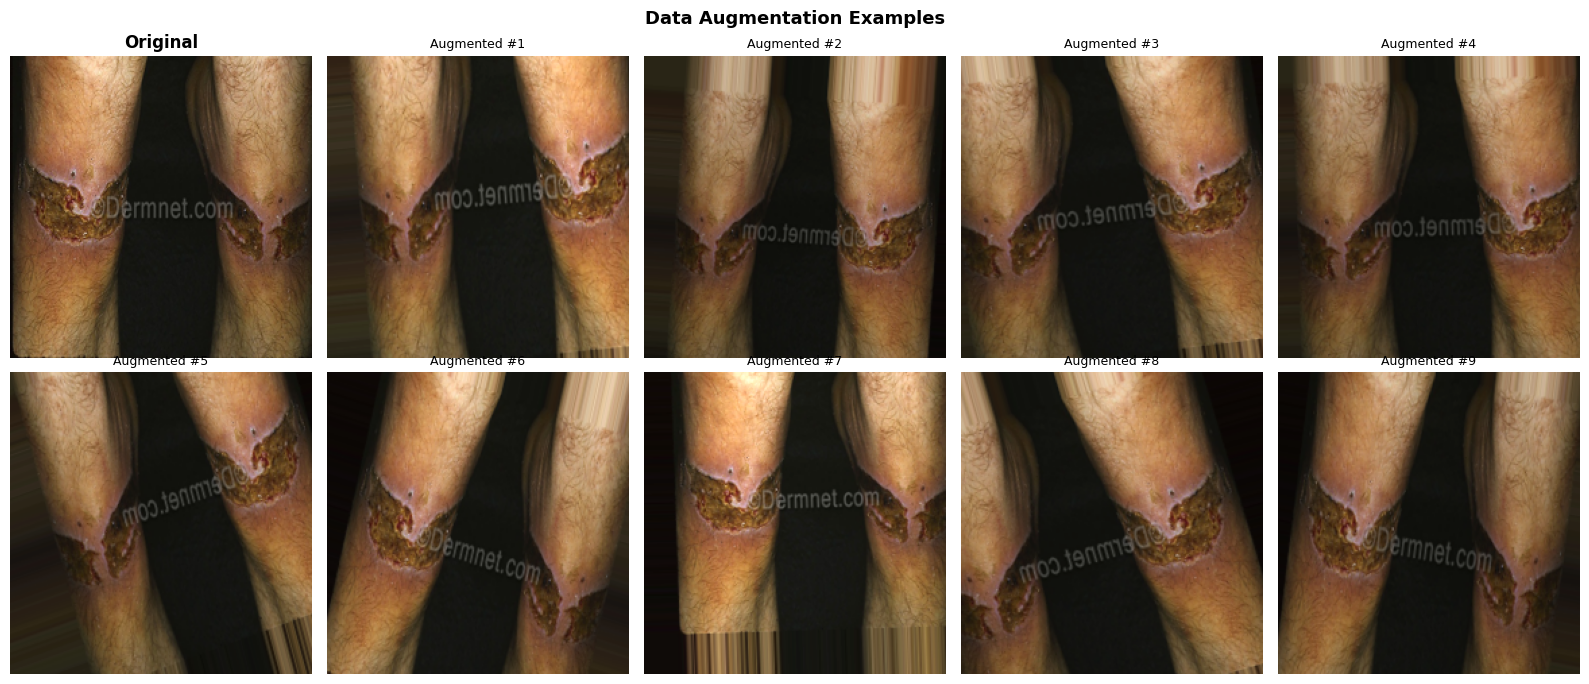

📊 Figure saved: fig3_augmentation.png


In [12]:
# ── Visualize augmentation effect ─────────────────────────────────────────────
sample_img_path = str(list((data_path / classes[0]).glob('*.jpg'))[0])
sample_img = Image.open(sample_img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
sample_arr = np.array(sample_img).reshape((1, IMG_SIZE, IMG_SIZE, 3))

aug_gen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.15, horizontal_flip=True, brightness_range=[0.8, 1.2]
).flow(sample_arr, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes[0][0].imshow(sample_img)
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    aug = next(aug_gen)[0].astype('uint8')
    ax.imshow(aug)
    ax.set_title(f'Augmented #{i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_augmentation.png', dpi=300, bbox_inches='tight')
plt.show()
print('📊 Figure saved: fig3_augmentation.png')

## 6. Model Architecture — EfficientNetB0 + Custom Head

In [13]:
def build_model(num_classes, img_size, dropout_rate, l2_reg, trainable_base=False):
    """
    EfficientNetB0 + custom classification head.
    Phase 1: trainable_base=False (feature extraction)
    Phase 2: trainable_base=True  (fine-tuning)
    """
    # Base model — pretrained on ImageNet, no top
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = trainable_base

    # Custom classification head
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)     # training=False keeps BN frozen in Phase 1
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(
            512,
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(l2_reg)
        )(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(
            256,
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(l2_reg)
        )(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='DermaAssist_EfficientNetB0')
    return model, base

# Build Phase 1 model
model, base_model = build_model(
    num_classes=CFG['NUM_CLASSES'],
    img_size=CFG['IMG_SIZE'],
    dropout_rate=CFG['DROPOUT'],
    l2_reg=CFG['L2_REG'],
    trainable_base=False
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CFG['PHASE1_LR']),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

# Count parameters
total     = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen    = total - trainable

print(f'Model: {model.name}')
print(f'Total parameters  : {total:>12,}')
print(f'Trainable (Phase 1): {trainable:>11,}')
print(f'Frozen (base)     : {frozen:>12,}')
print(f'Base model layers : {len(base_model.layers)}')
model.summary()

I0000 00:00:1788027728.936996      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788027728.940165      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model: DermaAssist_EfficientNetB0
Total parameters  :    4,844,461
Trainable (Phase 1):     792,330
Frozen (base)     :    4,052,131
Base model layers : 238


Model: "DermaAssist_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,844,461 (18.48 MB)

 Trainable params: 792,330 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 7. Training — Phase 1: Feature Extraction (Frozen Base)

In [14]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks_p1 = [
    ModelCheckpoint(
        CFG['CHECKPOINT_P1'],
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(CFG['LOG_P1'])
]

# ── Compute class weights for imbalance ───────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
train_labels_idx = [class_to_idx[l] for l in train_df['label']]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CFG['NUM_CLASSES']),
    y=train_labels_idx
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', {idx_to_class[k]: f'{v:.3f}' for k, v in class_weight_dict.items()})

# ── Train Phase 1 ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('PHASE 1: Feature Extraction (Base frozen)')
print('='*60)

t0 = time.time()
history_p1 = model.fit(
    train_gen,
    epochs=CFG['PHASE1_EPOCHS'],
    validation_data=val_gen,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict,
    verbose=1
)
t1 = time.time()
print(f'\nPhase 1 completed in {(t1-t0)/60:.1f} minutes')
print(f'Best val accuracy: {max(history_p1.history["val_accuracy"]):.4f}')

Class weights: {'1. Eczema 1677': '1.220', '10. Warts Molluscum and other Viral Infections - 2103': '0.973', '2. Melanoma 15.75k': '0.819', '3. Atopic Dermatitis - 1.25k': '1.364', '4. Basal Cell Carcinoma (BCC) 3323': '0.819', '5. Melanocytic Nevi (NV) - 7970': '0.819', '6. Benign Keratosis-like Lesions (BKL) 2624': '0.984', '7. Psoriasis pictures Lichen Planus and related diseases - 2k': '0.995', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k': '1.108', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k': '1.203'}

PHASE 1: Feature Extraction (Base frozen)
Epoch 1/20


2026-08-29 18:22:34.132819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:22:34.275732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:22:34.619865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:22:34.761029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:22:34.902915: E external/local_xla/xla/stream_

 45/448 ━━━━━━━━━━━━━━━━━━━━ 4:04 606ms/step - accuracy: 0.2656 - loss: 2.3310 - top3_acc: 0.5982

2026-08-29 18:23:17.974926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:23:18.115083: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:23:18.453248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:23:18.593500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:23:19.370050: E external/local_xla/xla/stream_

448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.4142 - loss: 1.7909 - top3_acc: 0.7570

...


Epoch 9: finished saving model to best_model_phase1.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 258s 576ms/step - accuracy: 0.6837 - loss: 1.0362 - top3_acc: 0.9340 - val_accuracy: 0.6888 - val_loss: 0.9887 - val_top3_acc: 0.9312 - learning_rate: 5.0000e-04
Epoch 10/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.6894 - loss: 1.0120 - top3_acc: 0.9409
Epoch 10: val_accuracy improved from 0.68882 to 0.69078, saving model to best_model_phase1.h5



Epoch 10: finished saving model to best_model_phase1.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 258s 576ms/step - accuracy: 0.6879 - loss: 1.0243 - top3_acc: 0.9379 - val_accuracy: 0.6908 - val_loss: 0.9848 - val_top3_acc: 0.9312 - learning_rate: 5.0000e-04
Epoch 11/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.7040 - loss: 0.9790 - top3_acc: 0.9466
Epoch 11: val_accuracy did not improve from 0.69078
448/448 ━━━━━━━━━━━━━━━━━━━━ 265s 591ms/step - accuracy: 0.6965 - loss: 0.9968 - top3_acc: 0.9425 - val_accuracy: 0.6875 - val_loss: 0.9910 - val_top3_acc: 0.9316 - learning_rate: 5.0000e-04
Epoch 12/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.7042 - loss: 0.9783 - top3_acc: 0.9418
Epoch 12: val_accuracy did not improve from 0.69078
448/448 ━━━━━━━━━━━━━━━━━━━━ 258s 575ms/step - accuracy: 0.7011 - loss: 0.9876 - top3_acc: 0.9408 - val_accuracy: 0.6901 - val_loss: 0.9879 - val_top3_acc: 0.9348 - learning_rate: 5.0000e-04
Epoch 13/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/


Epoch 13: finished saving model to best_model_phase1.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 258s 576ms/step - accuracy: 0.7052 - loss: 0.9754 - top3_acc: 0.9451 - val_accuracy: 0.6921 - val_loss: 0.9844 - val_top3_acc: 0.9280 - learning_rate: 5.0000e-04
Epoch 14/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.7088 - loss: 0.9630 - top3_acc: 0.9490
Epoch 14: val_accuracy did not improve from 0.69208
448/448 ━━━━━━━━━━━━━━━━━━━━ 261s 583ms/step - accuracy: 0.7168 - loss: 0.9498 - top3_acc: 0.9490 - val_accuracy: 0.6895 - val_loss: 0.9910 - val_top3_acc: 0.9355 - learning_rate: 5.0000e-04
Epoch 15/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.7065 - loss: 0.9687 - top3_acc: 0.9456
Epoch 15: val_accuracy did not improve from 0.69208
448/448 ━━━━━━━━━━━━━━━━━━━━ 261s 583ms/step - accuracy: 0.7114 - loss: 0.9557 - top3_acc: 0.9486 - val_accuracy: 0.6761 - val_loss: 1.0320 - val_top3_acc: 0.9322 - learning_rate: 5.0000e-04
Epoch 16/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/


Epoch 16: finished saving model to best_model_phase1.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 254s 568ms/step - accuracy: 0.7300 - loss: 0.9384 - top3_acc: 0.9518 - val_accuracy: 0.7022 - val_loss: 0.9790 - val_top3_acc: 0.9270 - learning_rate: 5.0000e-04
Epoch 17/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.7381 - loss: 0.9016 - top3_acc: 0.9559
Epoch 17: val_accuracy did not improve from 0.70218
448/448 ━━━━━━━━━━━━━━━━━━━━ 259s 579ms/step - accuracy: 0.7289 - loss: 0.9260 - top3_acc: 0.9531 - val_accuracy: 0.6973 - val_loss: 0.9781 - val_top3_acc: 0.9361 - learning_rate: 5.0000e-04
Epoch 18/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.7339 - loss: 0.9105 - top3_acc: 0.9579
Epoch 18: val_accuracy did not improve from 0.70218
448/448 ━━━━━━━━━━━━━━━━━━━━ 261s 583ms/step - accuracy: 0.7336 - loss: 0.9176 - top3_acc: 0.9566 - val_accuracy: 0.7015 - val_loss: 1.0011 - val_top3_acc: 0.9358 - learning_rate: 5.0000e-04
Epoch 19/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/


Epoch 20: finished saving model to best_model_phase1.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 267s 595ms/step - accuracy: 0.7383 - loss: 0.9126 - top3_acc: 0.9561 - val_accuracy: 0.7084 - val_loss: 0.9768 - val_top3_acc: 0.9374 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 20.

Phase 1 completed in 88.7 minutes
Best val accuracy: 0.7084


## 8. Training — Phase 2: Fine-Tuning (Unfreeze Top Layers)

In [15]:
# ── Load best Phase 1 weights, then unfreeze top layers ───────────────────────
model.load_weights(CFG['CHECKPOINT_P1'])

# Unfreeze EfficientNetB0 from layer index CFG['UNFREEZE_FROM'] onwards
base_model.trainable = True
for layer in base_model.layers[:CFG['UNFREEZE_FROM']]:
    layer.trainable = False

# Use a much lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CFG['PHASE2_LR']),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

trainable_p2 = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Phase 2 trainable parameters: {trainable_p2:,}')
print(f'Unfreezing from layer index: {CFG["UNFREEZE_FROM"]} of {len(base_model.layers)}')

callbacks_p2 = [
    ModelCheckpoint(
        CFG['CHECKPOINT_P2'],
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    CSVLogger(CFG['LOG_P2'])
]

print('\n' + '='*60)
print('PHASE 2: Fine-Tuning (Top layers unfrozen)')
print('='*60)

t0 = time.time()
history_p2 = model.fit(
    train_gen,
    epochs=CFG['PHASE2_EPOCHS'],
    validation_data=val_gen,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)
t1 = time.time()
print(f'\nPhase 2 completed in {(t1-t0)/60:.1f} minutes')
print(f'Best val accuracy: {max(history_p2.history["val_accuracy"]):.4f}')

# Load best overall model
model.load_weights(CFG['CHECKPOINT_P2'])

Phase 2 trainable parameters: 4,632,678
Unfreezing from layer index: 100 of 238

PHASE 2: Fine-Tuning (Top layers unfrozen)
Epoch 1/30


2026-08-29 19:51:29.022000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 19:51:29.176173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


422/448 ━━━━━━━━━━━━━━━━━━━━ 14s 550ms/step - accuracy: 0.4866 - loss: 1.6527 - top3_acc: 0.8138

2026-08-29 19:55:45.217926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 19:55:45.361815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 19:55:46.168968: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 19:55:46.309591: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.4885 - loss: 1.6466 - top3_acc: 0.8152
Epoch 1: val_accuracy improved from None to 0.57348, saving model to best_model_phase2.h5


...


Epoch 25: finished saving model to best_model_phase2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 256s 572ms/step - accuracy: 0.8050 - loss: 0.7477 - top3_acc: 0.9735 - val_accuracy: 0.7475 - val_loss: 0.9044 - val_top3_acc: 0.9466 - learning_rate: 1.0000e-05
Epoch 26/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.8121 - loss: 0.7148 - top3_acc: 0.9765
Epoch 26: val_accuracy improved from 0.74747 to 0.74910, saving model to best_model_phase2.h5



Epoch 26: finished saving model to best_model_phase2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 251s 560ms/step - accuracy: 0.8122 - loss: 0.7186 - top3_acc: 0.9747 - val_accuracy: 0.7491 - val_loss: 0.9025 - val_top3_acc: 0.9479 - learning_rate: 1.0000e-05
Epoch 27/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8167 - loss: 0.7165 - top3_acc: 0.9767
Epoch 27: val_accuracy improved from 0.74910 to 0.75138, saving model to best_model_phase2.h5



Epoch 27: finished saving model to best_model_phase2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 251s 561ms/step - accuracy: 0.8156 - loss: 0.7139 - top3_acc: 0.9774 - val_accuracy: 0.7514 - val_loss: 0.8963 - val_top3_acc: 0.9485 - learning_rate: 1.0000e-05
Epoch 28/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.8166 - loss: 0.6994 - top3_acc: 0.9753
Epoch 28: val_accuracy improved from 0.75138 to 0.75171, saving model to best_model_phase2.h5



Epoch 28: finished saving model to best_model_phase2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 249s 556ms/step - accuracy: 0.8114 - loss: 0.7124 - top3_acc: 0.9762 - val_accuracy: 0.7517 - val_loss: 0.8957 - val_top3_acc: 0.9479 - learning_rate: 1.0000e-05
Epoch 29/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.8175 - loss: 0.6997 - top3_acc: 0.9790
Epoch 29: val_accuracy did not improve from 0.75171
448/448 ━━━━━━━━━━━━━━━━━━━━ 251s 560ms/step - accuracy: 0.8181 - loss: 0.7001 - top3_acc: 0.9761 - val_accuracy: 0.7517 - val_loss: 0.8991 - val_top3_acc: 0.9472 - learning_rate: 1.0000e-05
Epoch 30/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8285 - loss: 0.6775 - top3_acc: 0.9781
Epoch 30: val_accuracy improved from 0.75171 to 0.75432, saving model to best_model_phase2.h5



Epoch 30: finished saving model to best_model_phase2.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 251s 560ms/step - accuracy: 0.8234 - loss: 0.6806 - top3_acc: 0.9785 - val_accuracy: 0.7543 - val_loss: 0.8935 - val_top3_acc: 0.9501 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 30.

Phase 2 completed in 130.6 minutes
Best val accuracy: 0.7543


## 9. Training Curves (Publication Figure)

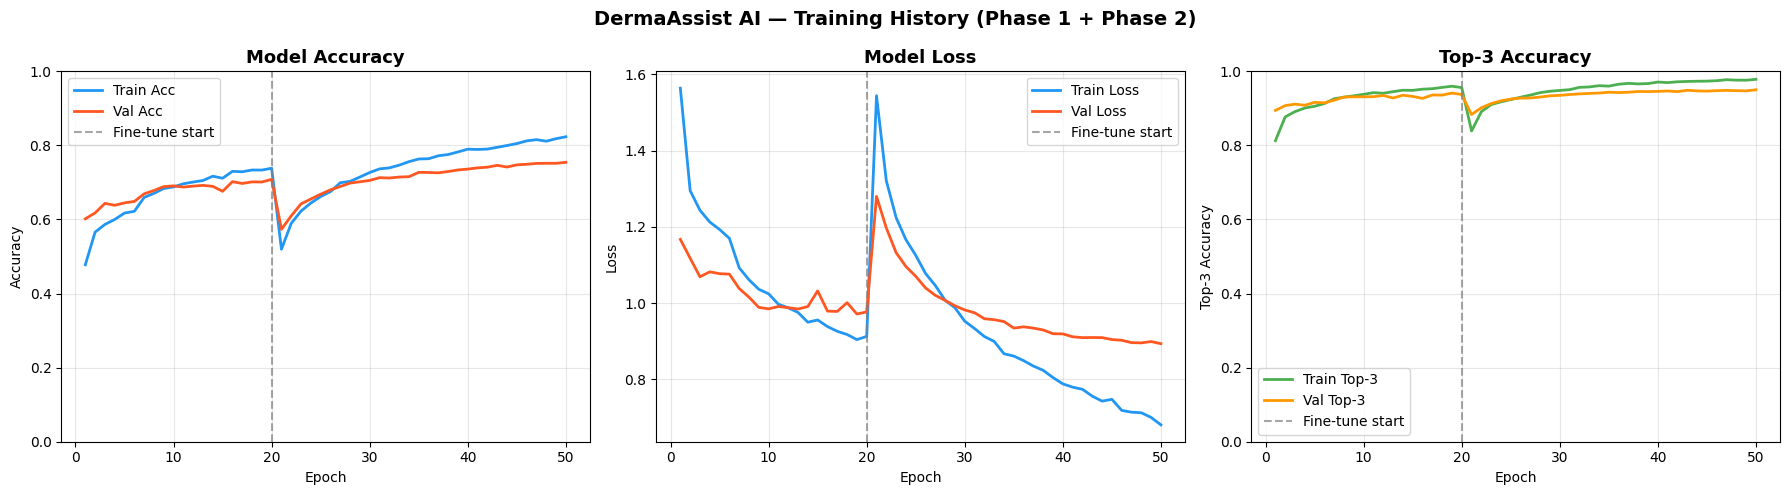

📊 Figure saved: fig4_training_curves.png


In [16]:
# ── Merge Phase 1 + Phase 2 histories ────────────────────────────────────────
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

full_history = merge_history(history_p1, history_p2)
p1_len = len(history_p1.history['accuracy'])

epochs_range = range(1, len(full_history['accuracy']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, full_history['accuracy'],     label='Train Acc',  color='#2196F3', lw=2)
ax.plot(epochs_range, full_history['val_accuracy'], label='Val Acc',    color='#FF5722', lw=2)
ax.axvline(p1_len, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_range, full_history['loss'],     label='Train Loss', color='#2196F3', lw=2)
ax.plot(epochs_range, full_history['val_loss'], label='Val Loss',   color='#FF5722', lw=2)
ax.axvline(p1_len, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax.set_title('Model Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── Top-3 Accuracy ────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(epochs_range, full_history['top3_acc'],     label='Train Top-3', color='#4CAF50', lw=2)
ax.plot(epochs_range, full_history['val_top3_acc'], label='Val Top-3',   color='#FF9800', lw=2)
ax.axvline(p1_len, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax.set_title('Top-3 Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Top-3 Accuracy')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

plt.suptitle('DermaAssist AI — Training History (Phase 1 + Phase 2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('📊 Figure saved: fig4_training_curves.png')

## 10. Evaluation on Test Set

In [17]:
# ── Predict on test set ───────────────────────────────────────────────────────
print('Running inference on test set...')
test_gen.reset()

y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes
class_labels = [idx_to_class[i] for i in range(CFG['NUM_CLASSES'])]

# ── Overall metrics ───────────────────────────────────────────────────────────
acc      = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_wtd   = f1_score(y_true, y_pred, average='weighted')
prec_wtd = precision_score(y_true, y_pred, average='weighted')
rec_wtd  = recall_score(y_true, y_pred, average='weighted')

# Top-3 accuracy
top3_correct = sum(
    y_true[i] in np.argsort(y_pred_probs[i])[-3:]
    for i in range(len(y_true))
)
top3_acc = top3_correct / len(y_true)

print('\n' + '='*55)
print('TEST SET RESULTS')
print('='*55)
print(f'  Top-1 Accuracy     : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Top-3 Accuracy     : {top3_acc:.4f}  ({top3_acc*100:.2f}%)')
print(f'  Precision (wtd)    : {prec_wtd:.4f}')
print(f'  Recall    (wtd)    : {rec_wtd:.4f}')
print(f'  F1-Score  (macro)  : {f1_macro:.4f}')
print(f'  F1-Score  (wtd)    : {f1_wtd:.4f}')
print('='*55)

Running inference on test set...
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step

2026-08-29 22:02:27.959655: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 22:02:28.101622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 22:02:28.473051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 22:02:28.613725: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 22:02:28.754373: E external/local_xla/xla/stream_

96/96 ━━━━━━━━━━━━━━━━━━━━ 56s 519ms/step

TEST SET RESULTS
  Top-1 Accuracy     : 0.7531  (75.31%)
  Top-3 Accuracy     : 0.9586  (95.86%)
  Precision (wtd)    : 0.7579
  Recall    (wtd)    : 0.7531
  F1-Score  (macro)  : 0.7374
  F1-Score  (wtd)    : 0.7536


In [18]:
# ── Per-class classification report ──────────────────────────────────────────
report = classification_report(
    y_true, y_pred,
    target_names=class_labels,
    digits=4
)
print('Classification Report:')
print(report)

# Save as DataFrame for paper table
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_labels,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T.round(4)
report_df.to_csv('per_class_metrics.csv')
print('\n📊 Per-class metrics saved: per_class_metrics.csv')

Classification Report:
                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677     0.5596    0.6733    0.6112       251
           10. Warts Molluscum and other Viral Infections - 2103     0.7119    0.6804    0.6958       316
                                              2. Melanoma 15.75k     0.9852    0.8880    0.9341       375
                                    3. Atopic Dermatitis - 1.25k     0.6779    0.6267    0.6513       225
                              4. Basal Cell Carcinoma (BCC) 3323     0.8477    0.9200    0.8824       375
                                 5. Melanocytic Nevi (NV) - 7970     0.8591    0.8453    0.8522       375
                     6. Benign Keratosis-like Lesions (BKL) 2624     0.7652    0.8045    0.7844       312
   7. Psoriasis pictures Lichen Planus and related diseases - 2k     0.6385    0.5390    0.5845       308
          8. Seborrhei

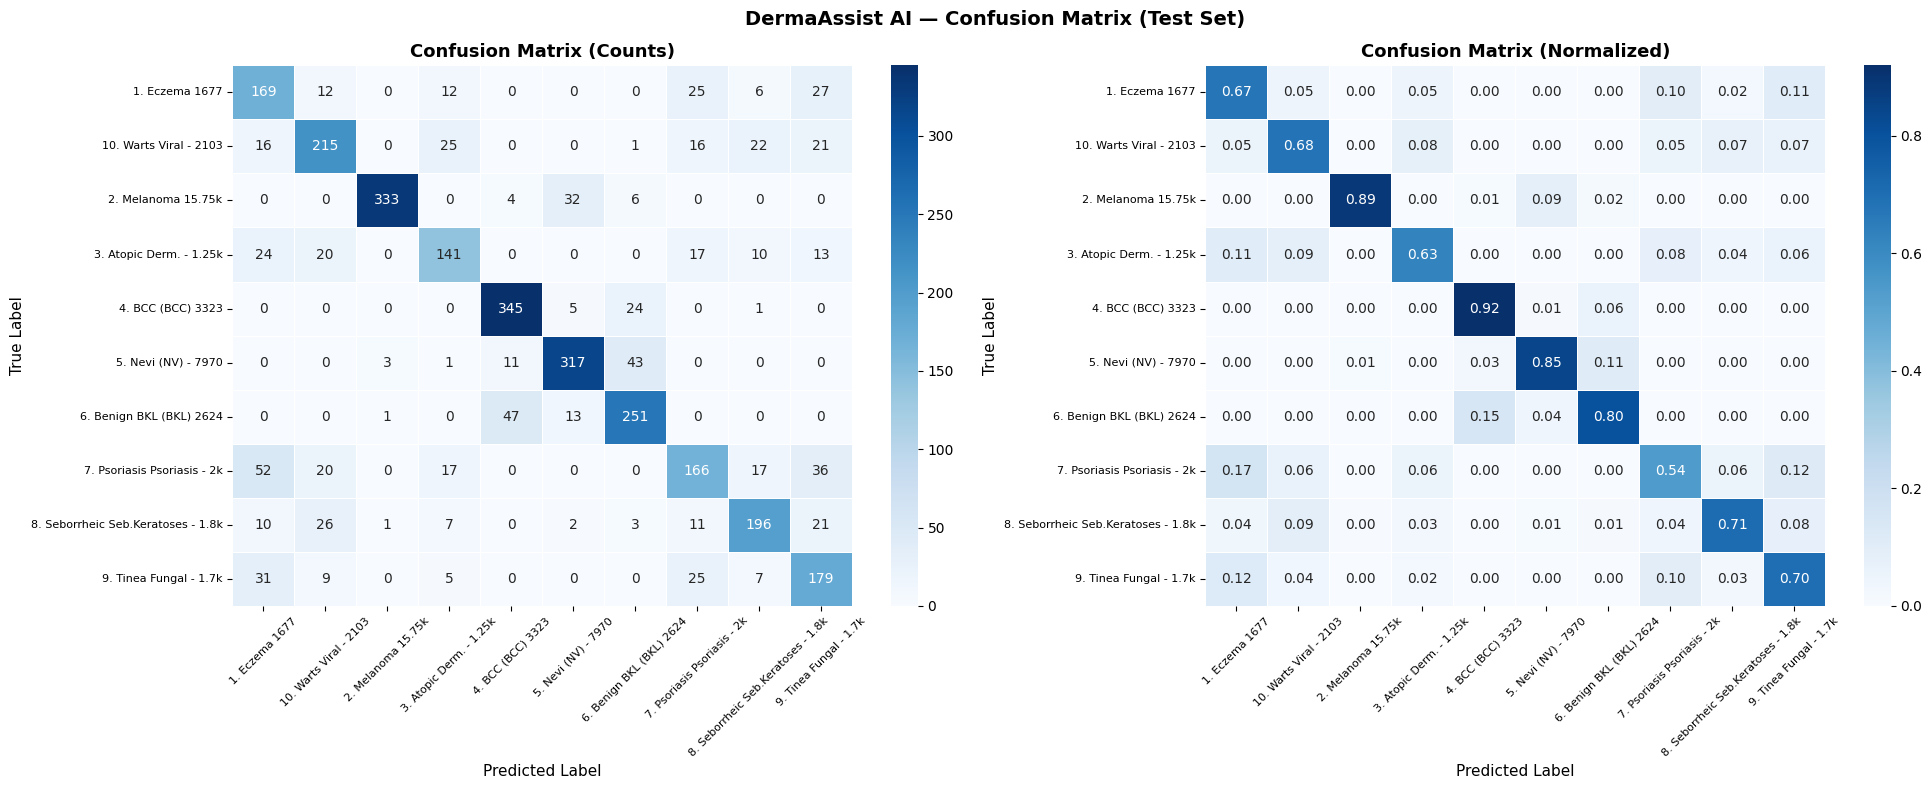

📊 Figure saved: fig5_confusion_matrix.png


In [19]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalized

# Short class names for display
short_names = [
    c.replace('Ringworm Candidiasis and other Fungal Infections', 'Fungal')
     .replace('pictures Lichen Planus and related diseases', 'Psoriasis')
     .replace('Keratoses and other Benign Tumors', 'Seb.Keratoses')
     .replace('Molluscum and other Viral Infections', 'Viral')
     .replace('Melanocytic Nevi', 'Nevi')
     .replace('Keratosis-like Lesions', 'BKL')
     .replace('Basal Cell Carcinoma', 'BCC')
     .replace('Atopic Dermatitis', 'Atopic Derm.')
    for c in class_labels
]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix (Counts)', 'Confusion Matrix (Normalized)'],
    ['d', '.2f']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=short_names, yticklabels=short_names,
        ax=ax, linewidths=0.5, cbar=True
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('DermaAssist AI — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('📊 Figure saved: fig5_confusion_matrix.png')

## 11. Grad-CAM Explainability (Publication Figure)

Base model output shape: (None, 7, 7, 1280)
Head layers: ['global_average_pooling2d', 'batch_normalization', 'dense', 'dropout', 'dense_1', 'dropout_1', 'dense_2']
✅ Grad-CAM model ready


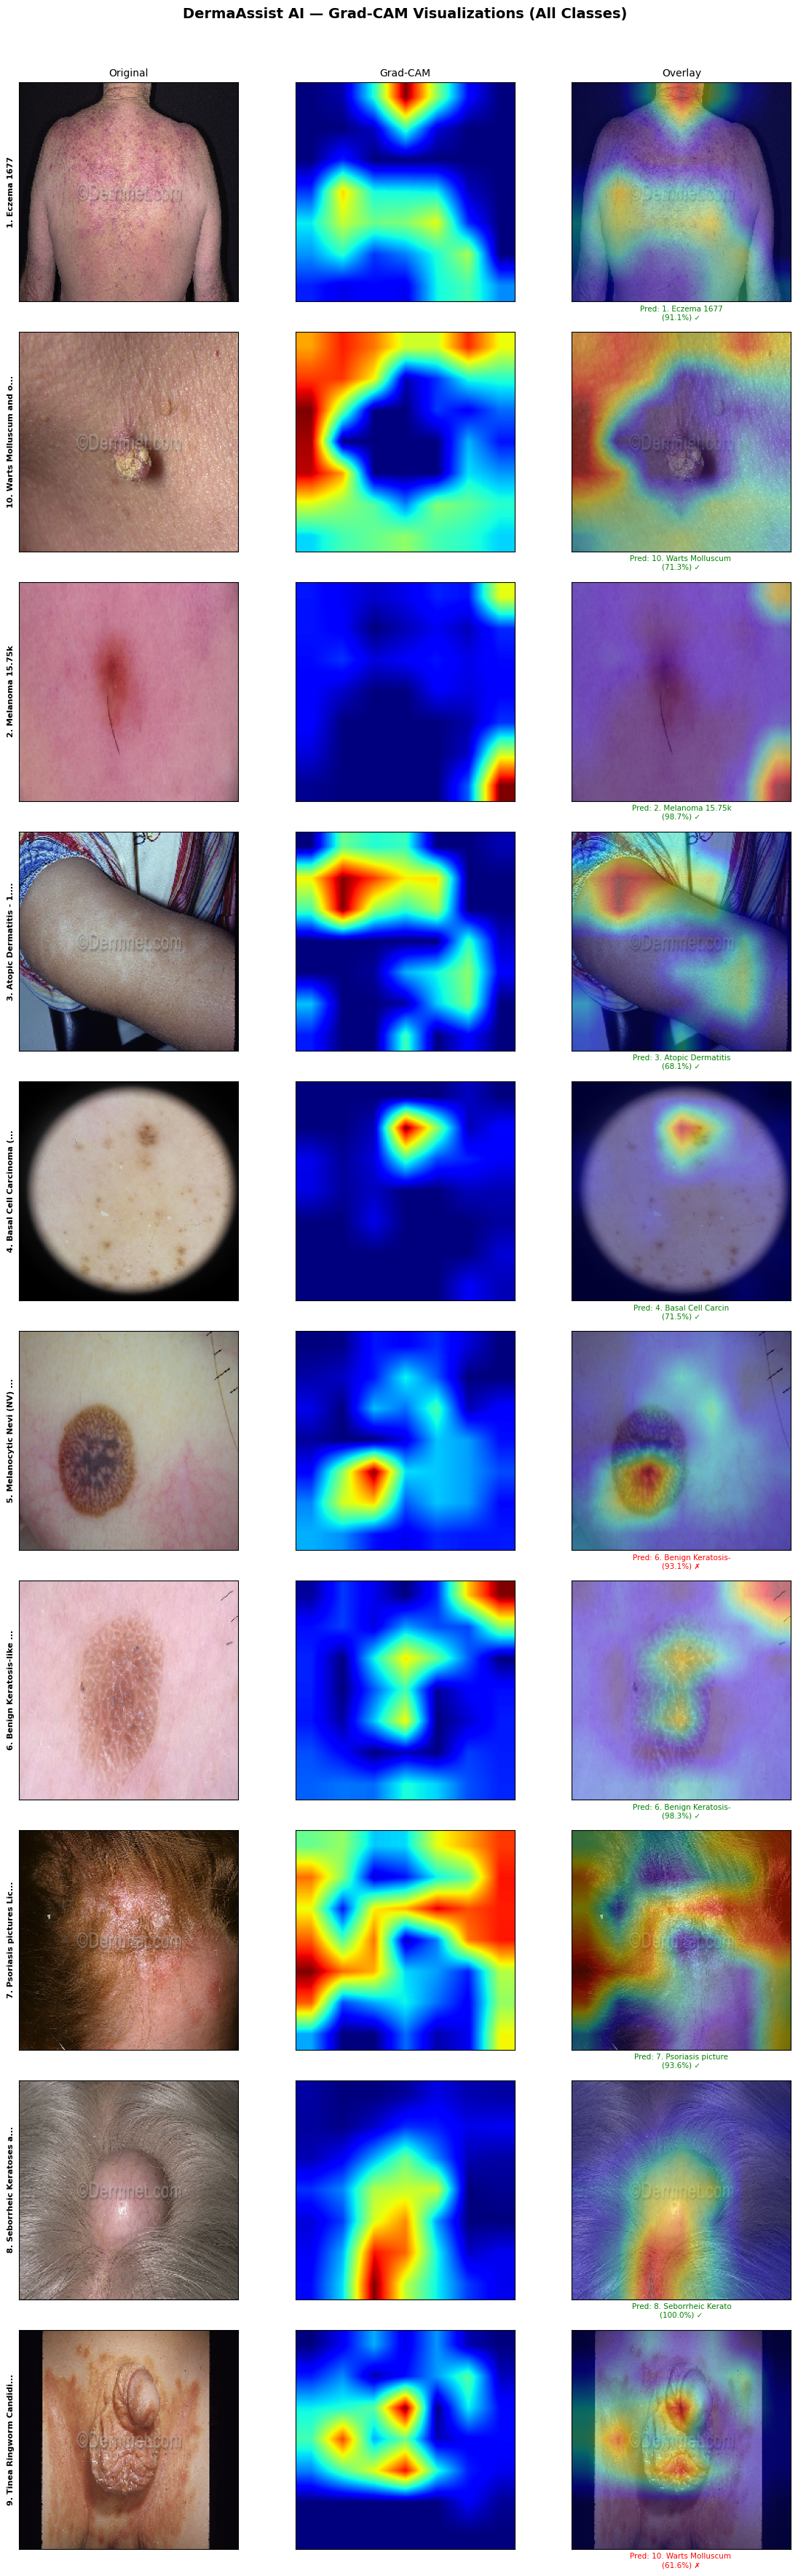

📊 Figure saved: fig6_gradcam.png


In [31]:
# ══════════════════════════════════════════════════════════════════════════
# Grad-CAM Explainability — Publication Figure (all-in-one, fixed)
# ══════════════════════════════════════════════════════════════════════════

# ── Setup ─────────────────────────────────────────────────────────────────
# EfficientNetB0 was loaded with include_top=False, so its own output
# IS the last conv feature map — no need to dig into 'top_activation'.
efficientnet_submodel = model.layers[1]  # index 1 is EfficientNetB0
head_layers = model.layers[2:]           # everything after the base model

print(f'Base model output shape: {efficientnet_submodel.output_shape}')
print(f'Head layers: {[l.name for l in head_layers]}')

# ── Grad-CAM function (manual forward pass — avoids nested-model graph bug) ─
def get_gradcam_heatmap(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array_pp = tf.keras.applications.efficientnet.preprocess_input(img_array.copy())
    inp = np.expand_dims(img_array_pp, 0)

    with tf.GradientTape() as tape:
        conv_out = efficientnet_submodel(inp, training=False)
        tape.watch(conv_out)

        x = conv_out
        for layer in head_layers:
            x = layer(x, training=False)
        preds = x

        pred_idx = tf.argmax(preds[0])
        class_score = preds[:, pred_idx]

    grads = tape.gradient(class_score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(tf.maximum(heatmap, 0))
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    jet_cmap = plt.get_cmap('jet')  # explicit lookup — 'cm' global got shadowed earlier in the notebook
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = (jet_cmap(heatmap_resized)[:, :, :3] * 255).astype('uint8')
    original = img_array.astype('uint8')
    overlay  = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)

    return original, heatmap_colored, overlay, int(pred_idx.numpy()), preds.numpy()[0]

print('✅ Grad-CAM model ready')

# ── Grad-CAM for 1 sample per class (publication figure) ───────────────────
n_cols = 3  # original | heatmap | overlay
n_rows = CFG['NUM_CLASSES']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3.5))

for row_idx, cls in enumerate(sorted(classes)):
    cls_path = data_path / cls
    sample_files = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.png'))
    if not sample_files:
        continue

    sample_file = random.choice(sample_files)

    try:
        original, heatmap, overlay, pred_idx, probs = get_gradcam_heatmap(str(sample_file))
        pred_cls   = idx_to_class[pred_idx]
        confidence = probs[pred_idx] * 100

        axes[row_idx, 0].imshow(original)
        short_cls = cls[:25] + ('...' if len(cls) > 25 else '')
        axes[row_idx, 0].set_ylabel(short_cls, fontsize=8, fontweight='bold')
        axes[row_idx, 0].set_title('Original' if row_idx == 0 else '', fontsize=10)

        axes[row_idx, 1].imshow(heatmap)
        axes[row_idx, 1].set_title('Grad-CAM' if row_idx == 0 else '', fontsize=10)

        axes[row_idx, 2].imshow(overlay)
        correct = (pred_cls == cls)
        color = 'green' if correct else 'red'
        label = f'Pred: {pred_cls[:20]}\n({confidence:.1f}%) {"✓" if correct else "✗"}'
        axes[row_idx, 2].set_title(
            'Overlay' if row_idx == 0 else '', fontsize=10
        )
        axes[row_idx, 2].set_xlabel(label, fontsize=7.5, color=color)

        for ax in axes[row_idx]:
            ax.set_xticks([]); ax.set_yticks([])

    except Exception as e:
        print(f'Error on {cls}: {e}')

plt.suptitle('DermaAssist AI — Grad-CAM Visualizations (All Classes)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_gradcam.png', dpi=300, bbox_inches='tight')
plt.show()
print('📊 Figure saved: fig6_gradcam.png')

## 12. Top-3 Inference Module (DermaAssist Core)

In [23]:
def predict_top3(img_path, model, idx_to_class, img_size=224):
    """
    DermaAssist AI inference function.
    Returns top-3 predictions with confidence scores.
    This is the function that plugs into the app.
    """
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    t0 = time.time()
    probs = model.predict(img_array, verbose=0)[0]
    inference_time_ms = (time.time() - t0) * 1000

    top3_indices = np.argsort(probs)[::-1][:3]
    results = [
        {
            'rank':       i + 1,
            'disease':    idx_to_class[idx],
            'confidence': float(probs[idx]),
            'percentage': f'{probs[idx]*100:.2f}%'
        }
        for i, idx in enumerate(top3_indices)
    ]
    return results, inference_time_ms


# ── Demo: run on 5 random test images ────────────────────────────────────────
print('Top-3 Inference Demo\n' + '='*55)
sample_test = test_df.sample(5, random_state=SEED)

inference_times = []
for _, row in sample_test.iterrows():
    results, t_ms = predict_top3(row['path'], model, idx_to_class)
    inference_times.append(t_ms)
    print(f'\nImage : {Path(row["path"]).name}')
    print(f'True  : {row["label"]}')
    for r in results:
        marker = '✓' if r['disease'] == row['label'] else ' '
        print(f'  #{r["rank"]} {marker} {r["disease"]:<55} {r["percentage"]}')
    print(f'Inference time: {t_ms:.1f} ms')

print(f'\nAverage inference time: {np.mean(inference_times):.1f} ms')
print(f'(on CPU — GPU will be faster)')

Top-3 Inference Demo


2026-08-29 22:02:52.676764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 22:02:52.812568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 22:02:53.581561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 22:02:53.717143: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Image : t-epidermal-cyst-178.jpg
True  : 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
  #1 ✓ 8. Seborrheic Keratoses and other Benign Tumors - 1.8k  67.82%
  #2   1. Eczema 1677                                          20.76%
  #3   7. Psoriasis pictures Lichen Planus and related diseases - 2k 7.28%
Inference time: 12405.4 ms

Image : ISIC_0032700.jpg
True  : 5. Melanocytic Nevi (NV) - 7970
  #1   4. Basal Cell Carcinoma (BCC) 3323                      96.42%
  #2   6. Benign Keratosis-like Lesions (BKL) 2624             3.52%
  #3 ✓ 5. Melanocytic Nevi (NV) - 7970                         0.06%
Inference time: 89.5 ms

Image : ISIC_0061105.jpg
True  : 4. Basal Cell Carcinoma (BCC) 3323
  #1 ✓ 4. Basal Cell Carcinoma (BCC) 3323                      91.44%
  #2   6. Benign Keratosis-like Lesions (BKL) 2624             8.55%
  #3   5. Melanocytic Nevi (NV) - 7970                         0.01%
Inference time: 84.3 ms

Image : v-sebaceous-hyperplasia-9.jpg
True  : 8. Seborrheic K

## 13. Ablation Study — Two-Phase Training Analysis

In [24]:
# ── Load Phase 1 model and evaluate separately for ablation ───────────────────
# This quantifies the contribution of fine-tuning
print('Loading Phase 1 model for ablation comparison...')

model_p1_only, _ = build_model(
    num_classes=CFG['NUM_CLASSES'],
    img_size=CFG['IMG_SIZE'],
    dropout_rate=CFG['DROPOUT'],
    l2_reg=CFG['L2_REG'],
    trainable_base=False
)
model_p1_only.compile(
    optimizer='adam', loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_p1_only.load_weights(CFG['CHECKPOINT_P1'])

test_gen.reset()
y_pred_p1 = np.argmax(model_p1_only.predict(test_gen, verbose=1), axis=1)

acc_p1      = accuracy_score(y_true, y_pred_p1)
f1_p1       = f1_score(y_true, y_pred_p1, average='weighted')
acc_p2      = accuracy_score(y_true, y_pred)
f1_p2       = f1_score(y_true, y_pred, average='weighted')

# ── Ablation table ────────────────────────────────────────────────────────────
ablation_df = pd.DataFrame({
    'Configuration': [
        'Phase 1 only (frozen base)',
        'Phase 1 + Phase 2 (fine-tuned)'
    ],
    'Trainable Layers': ['Custom head only', f'Custom head + EfficientNet [{CFG["UNFREEZE_FROM"]}:]'],
    'Accuracy': [f'{acc_p1:.4f}', f'{acc_p2:.4f}'],
    'F1 (weighted)': [f'{f1_p1:.4f}', f'{f1_p2:.4f}'],
    'Improvement': ['-', f'+{(acc_p2-acc_p1)*100:.2f}% acc']
})

print('\nAblation Study — Training Strategy:')
print(ablation_df.to_string(index=False))
ablation_df.to_csv('ablation_training_strategy.csv', index=False)
print('\n📊 Ablation table saved: ablation_training_strategy.csv')

Loading Phase 1 model for ablation comparison...
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step

Ablation Study — Training Strategy:
                 Configuration                  Trainable Layers Accuracy F1 (weighted) Improvement
    Phase 1 only (frozen base)                  Custom head only   0.6993        0.6984           -
Phase 1 + Phase 2 (fine-tuned) Custom head + EfficientNet [100:]   0.7531        0.7536  +5.37% acc

📊 Ablation table saved: ablation_training_strategy.csv


## 14. Comparison with Prior Work (Publication Table)

In [25]:
# ── Build comparison table against literature ─────────────────────────────────
# Fill in your actual results after training

comparison_data = {
    'Study': [
        'Noor et al. (2025)',
        'Ours — Phase 1 only',
        'Ours — Phase 1 + Phase 2 (DermaAssist AI)',
    ],
    'Model': [
        'EfficientNetB0+B2+ResNet50 Ensemble',
        'EfficientNetB0 (feature extraction)',
        'EfficientNetB0 (two-phase fine-tuning)',
    ],
    'Dataset': [
        'ismailpromus (27,153)',
        'ismailpromus (balanced)',
        'ismailpromus (balanced)',
    ],
    'Classes': [10, 10, 10],
    'Accuracy': [
        '~0.97 (reported)',
        f'{acc_p1:.4f}',
        f'{acc_p2:.4f}',
    ],
    'F1 (weighted)': [
        'N/A',
        f'{f1_p1:.4f}',
        f'{f1_p2:.4f}',
    ],
    'Top-3 Acc': [
        'N/A',
        'N/A',
        f'{top3_acc:.4f}',
    ],
    'Deployment': [
        'Not reported',
        'Offline (.h5)',
        'Offline (.h5) + TFLite + Cloud AI',
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print('Comparison with Prior Work:')
print(comparison_df.to_string(index=False))
comparison_df.to_csv('comparison_with_prior_work.csv', index=False)
print('\n📊 Comparison table saved: comparison_with_prior_work.csv')

Comparison with Prior Work:
                                    Study                                  Model                 Dataset  Classes         Accuracy F1 (weighted) Top-3 Acc                        Deployment
                       Noor et al. (2025)    EfficientNetB0+B2+ResNet50 Ensemble   ismailpromus (27,153)       10 ~0.97 (reported)           N/A       N/A                      Not reported
                      Ours — Phase 1 only    EfficientNetB0 (feature extraction) ismailpromus (balanced)       10           0.6993        0.6984       N/A                     Offline (.h5)
Ours — Phase 1 + Phase 2 (DermaAssist AI) EfficientNetB0 (two-phase fine-tuning) ismailpromus (balanced)       10           0.7531        0.7536    0.9586 Offline (.h5) + TFLite + Cloud AI

📊 Comparison table saved: comparison_with_prior_work.csv


## 15. Model Export — .h5 and TFLite

In [26]:
# ── Save full model ───────────────────────────────────────────────────────────
model.save('dermaassist_model_final.h5')
print('✅ Full model saved: dermaassist_model_final.h5')

# ── Save class index mapping ──────────────────────────────────────────────────
with open('class_indices.json', 'w') as f:
    json.dump({'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class}, f, indent=2)
print('✅ Class indices saved: class_indices.json')

# ── Convert to TFLite (for on-device deployment) ──────────────────────────────
print('\nConverting to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # dynamic range quantization
tflite_model = converter.convert()

with open(CFG['TFLITE_PATH'], 'wb') as f:
    f.write(tflite_model)

h5_size     = os.path.getsize('dermaassist_model_final.h5') / 1e6
tflite_size = os.path.getsize(CFG['TFLITE_PATH']) / 1e6
reduction   = (1 - tflite_size / h5_size) * 100

print(f'✅ TFLite model saved: {CFG["TFLITE_PATH"]}')
print(f'   .h5 size     : {h5_size:.1f} MB')
print(f'   .tflite size : {tflite_size:.1f} MB ({reduction:.1f}% reduction)')

✅ Full model saved: dermaassist_model_final.h5
✅ Class indices saved: class_indices.json

Converting to TFLite...
INFO:tensorflow:Assets written to: /tmp/tmp82gz3x0k/assets


INFO:tensorflow:Assets written to: /tmp/tmp82gz3x0k/assets


Saved artifact at '/tmp/tmp82gz3x0k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133590398620240: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133590398626000: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133592630526608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133592630535632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133592630536208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133592630526224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133592630534672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133592630527376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133592630529104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133592630529296: TensorSpec(shape=(), dtype=tf.resource, name

W0000 00:00:1788041023.004515      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788041023.004585      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788041023.212390      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


✅ TFLite model saved: dermaassist_model.tflite
   .h5 size     : 57.0 MB
   .tflite size : 5.4 MB (90.6% reduction)


In [27]:
# ── Verify TFLite inference ───────────────────────────────────────────────────
print('Verifying TFLite model...')
interpreter = tf.lite.Interpreter(model_path=CFG['TFLITE_PATH'])
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f'Input shape  : {input_details[0]["shape"]}')
print(f'Output shape : {output_details[0]["shape"]}')

# Test on one image
sample_path = test_df['path'].iloc[0]
img = tf.keras.preprocessing.image.load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
img_arr = tf.keras.applications.efficientnet.preprocess_input(
    np.expand_dims(tf.keras.preprocessing.image.img_to_array(img), 0).astype('float32')
)

t0 = time.time()
interpreter.set_tensor(input_details[0]['index'], img_arr)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]['index'])
tflite_ms = (time.time() - t0) * 1000

tflite_pred = idx_to_class[np.argmax(tflite_output[0])]
keras_pred  = idx_to_class[np.argmax(model.predict(img_arr, verbose=0)[0])]

print(f'\nTFLite prediction : {tflite_pred}')
print(f'Keras  prediction : {keras_pred}')
print(f'Match             : {tflite_pred == keras_pred}')
print(f'TFLite inference  : {tflite_ms:.1f} ms')
print('\n✅ TFLite model verified and ready for deployment')

Verifying TFLite model...
Input shape  : [  1 224 224   3]
Output shape : [ 1 10]

TFLite prediction : 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
Keras  prediction : 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
Match             : True
TFLite inference  : 40.3 ms

✅ TFLite model verified and ready for deployment


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 16. Final Results Summary

In [28]:
# ── Print complete results for paper ─────────────────────────────────────────
print('\n' + '='*60)
print('  DERMAASSIST AI — FINAL RESULTS SUMMARY')
print('  (Copy these numbers into your paper)')
print('='*60)
print(f'\n  Dataset       : ismailpromus Skin Diseases (Kaggle)')
print(f'  Classes       : {CFG["NUM_CLASSES"]} skin disease categories')
print(f'  Total images  : {len(balanced_df):,} (after balancing)')
print(f'  Train/Val/Test: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}')
print(f'  Base model    : EfficientNetB0 (ImageNet pretrained)')
print(f'  Optimizer     : Adam (Phase1 LR={CFG["PHASE1_LR"]}, Phase2 LR={CFG["PHASE2_LR"]})')
print(f'  Batch size    : {CFG["BATCH_SIZE"]}')
print()
print(f'  ── Test Set Performance ──────────────────────────────')
print(f'  Top-1 Accuracy     : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Top-3 Accuracy     : {top3_acc:.4f} ({top3_acc*100:.2f}%)')
print(f'  Precision (wtd)    : {prec_wtd:.4f}')
print(f'  Recall    (wtd)    : {rec_wtd:.4f}')
print(f'  F1-Score  (macro)  : {f1_macro:.4f}')
print(f'  F1-Score  (wtd)    : {f1_wtd:.4f}')
print()
print(f'  ── Model Size ────────────────────────────────────────')
print(f'  .h5 model size     : {os.path.getsize("dermaassist_model_final.h5")/1e6:.1f} MB')
print(f'  TFLite model size  : {os.path.getsize(CFG["TFLITE_PATH"])/1e6:.1f} MB')
print(f'  Avg inference time : {np.mean(inference_times):.1f} ms (CPU)')
print()
print(f'  ── Training ──────────────────────────────────────────')
print(f'  Phase 1 epochs     : {len(history_p1.history["accuracy"])}')
print(f'  Phase 2 epochs     : {len(history_p2.history["accuracy"])}')
print(f'  Best Phase 1 val acc: {max(history_p1.history["val_accuracy"]):.4f}')
print(f'  Best Phase 2 val acc: {max(history_p2.history["val_accuracy"]):.4f}')
print('='*60)

# ── List all saved files ──────────────────────────────────────────────────────
print('\n  Files saved (for paper and deployment):')
files = [
    'dermaassist_model_final.h5',
    CFG['TFLITE_PATH'],
    'class_indices.json',
    'config.json',
    'split_train.csv', 'split_val.csv', 'split_test.csv',
    'per_class_metrics.csv',
    'ablation_training_strategy.csv',
    'comparison_with_prior_work.csv',
    CFG['LOG_P1'], CFG['LOG_P2'],
    'fig1_class_distribution.png',
    'fig2_sample_images.png',
    'fig3_augmentation.png',
    'fig4_training_curves.png',
    'fig5_confusion_matrix.png',
    'fig6_gradcam.png',
]
for f in files:
    exists = '✅' if os.path.exists(f) else '⏳'
    print(f'    {exists} {f}')


  DERMAASSIST AI — FINAL RESULTS SUMMARY
  (Copy these numbers into your paper)

  Dataset       : ismailpromus Skin Diseases (Kaggle)
  Classes       : 10 skin disease categories
  Total images  : 20,463 (after balancing)
  Train/Val/Test: 14,324 / 3,069 / 3,070
  Base model    : EfficientNetB0 (ImageNet pretrained)
  Optimizer     : Adam (Phase1 LR=0.001, Phase2 LR=1e-05)
  Batch size    : 32

  ── Test Set Performance ──────────────────────────────
  Top-1 Accuracy     : 0.7531 (75.31%)
  Top-3 Accuracy     : 0.9586 (95.86%)
  Precision (wtd)    : 0.7579
  Recall    (wtd)    : 0.7531
  F1-Score  (macro)  : 0.7374
  F1-Score  (wtd)    : 0.7536

  ── Model Size ────────────────────────────────────────
  .h5 model size     : 57.0 MB
  TFLite model size  : 5.4 MB
  Avg inference time : 2553.1 ms (CPU)

  ── Training ──────────────────────────────────────────
  Phase 1 epochs     : 20
  Phase 2 epochs     : 30
  Best Phase 1 val acc: 0.7084
  Best Phase 2 val acc: 0.7543

  Files saved 

In [29]:
print("Hello")

Hello
